<a href="https://colab.research.google.com/github/AlHartMos/IEU_courses/blob/main/simulating_and_modeling/2_3_Generating_Discreet_Random_Variables_Excercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generating Discreet Random Variables

A random variable is a variable whose value is unknown or a function that assigns values to each of an experiment's outcomes.

Random variables are often designated by letters and can be classified as discrete (variables with specific values) or continuous, (variables which can take any value within a range).

The use of random variables is most common in probability and statistics, where they are used to quantify outcomes of random occurrences.

**Random variables are required to be measurable and are typically real numbers.**

**A random variable is different from an algebraic variable.**

The variable in an algebraic equation is an unknown value that can be calculated. For example, the equation 10 + x = 13 shows that we can calculate the specific value for x which is 3.

On the other hand, a random variable has a set of values, and any of those values could be the resulting outcome. For example, the letter X may be designated to represent the sum of the resulting numbers after three dice are rolled. In this case, X could be 3 (1 + 1+ 1), 18 (6 + 6 + 6), or somewhere between 3 and 18.

A random variable has a probability distribution that represents the likelihood that any of the possible values would occur.

Let’s say that the random variable, A, is the number on the top face of a die when it is rolled once. The possible values for A will then be 1, 2, 3, 4, 5, and 6. The probability of each of these values is 1/6 as they are all equally likely to be the value of A.

For instance, the probability of getting a 3, or P (A=3), when a die is thrown is 1/6, and so is the probability of having a 4 or a 2 or any other number on all six faces of a die. Note that the sum of all probabilities is 1.


# Simulating Discrete Random Variables

In order to introduce discrete random variables, let’s inspect each of the words:

* **Variable**: this means that there is some process that takes some value. It is a synonym of function as you have studied in other mathematics classes.
* **Random**: this means that the variable takes values according to some probability distribution.
* **Discrete**: this refers to the possible values that the variable can take. In this case it is a countable (possibly infinite) set of values.

In general we denote a random variable as $X$ and its possible values as $𝕏 = \{x_1,x_2,x_3,… \}$. The set $𝕏$ is called the sample space of $X$. In real-life we do not know which value in the set $𝕏$ the random variable will take.
Let’s consider some examples.

* The number of donuts sold in a day in a shop is a discrete random variable which can take values $\{ 0, 1, 2, 3,... \}$ , that is the non-negative integers. In this case the number of possible values is infinite.
* The outcome of a pregnancy test can be either positive or negative but in advance we do not know which one. So this can be denoted as a discrete random variable taking values in $\{ negative, positive \}$. It is customary to denote the elements of the sample space $X$ as number. For instance, $negative = 0$ and $positive = 1$ and the sample space would be $X \in \{ 0,1 \}$.
* The number shown on the face of a dice once thrown is a discrete random variable taking values in $X \in \{ 1, 2, 3, 4, 5, 6 \}$.

## Probability Mass Function (PMF)

The outcome of a discrete random variable is in general unknown, but we want to associate to each outcome, that is to each element of $𝕏$, a number describing its likelihood. Such a number is called a probability and it is in general denoted as $P$.

The $pmf$ of a random variable $X$ with sample space $𝕏$ is defined as

$p(x) = P(X = x),$    $\ for \ all \ x ∈ 𝕏$

$Pmf$ must obey two conditions:

1. $p(x) ≥ 0 \ for \ all \ x ∈ 𝕏$

2. $\sum_{x\in𝕏}{p(x)} = 1$

In other words, the $pmf$ associated to each outcome is a non-negative number such that the sum of all these numbers is equal to one.

Let’s consider an example. Suppose a biased dice is thrown such that the numbers 3 and 6 are twice as likely to appear than the other numbers. A pmf describing such a situation is the following:

$x$    |  1  |  2  |  3  |  4  |  5  |  6  |
-------|-----|-----|-----|-----|-----|-----|
$p(x)$ | 1/8 | 1/8 | 2/8 | 1/8 | 1/8 | 2/8 |





In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math

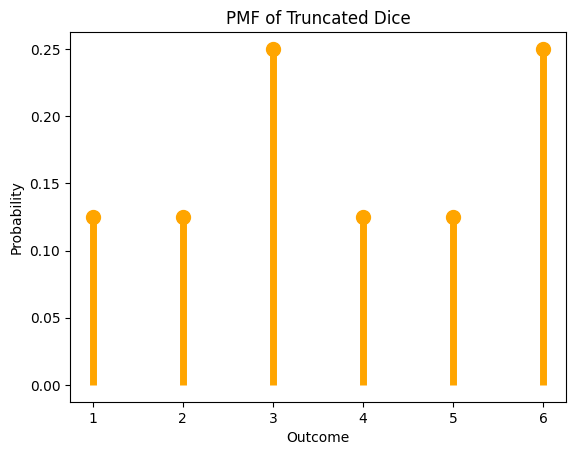

In [3]:
probabilities = [1/8, 1/8, 2/8, 1/8, 1/8, 2/8]
outcomes = [1, 2, 3, 4, 5, 6]

plt.vlines(outcomes, 0, probabilities, colors='orange', lw=5)
plt.plot(outcomes, probabilities, 'o', color='orange', markersize=10)
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.title("PMF of Truncated Dice")
plt.show()

#Cummulative Distribution Function

We now define what is usually called the cumulative distribution function (cdf) of a random variable X.

The $cdf$ of $X$ at the point $x ϵ 𝕏$ is

$F(x) = P (X ≤ x) = \sum_{y≤x}{p(y)} $

That is the probability that X is less or equal to x or equal to the sum of the pmf of X for all values less than x.

Let’s consider the dice example to illustrate the idea of cdf and consider the following values x:

**x = 0**: we compute F(0) = P(X ≤ 0) = 0 since X cannot take any values less than or equal to zero;

**x = 0.9** we compute F(0.9) = P(X ≤ 0.9) = 0 same reasoning as before;

**x = 1**: we compute F(1) = P(X ≤ 1) = 1/8 since X can take the value 1 with probability ⅛;

**x = 1.5**: we compute F(1.5) = P(X ≤ 1.5) = 1/8 same reasoning as before;

**x = 3.2**: we compute F(3.2) = P(X ≤ 3.2) = P(x = 1) + P(x = 2) + P(x = 3) = ⅛ +⅛ + 2/8 = 0.5 since X can take the values 1, 2 and 3 which are less than 3.2


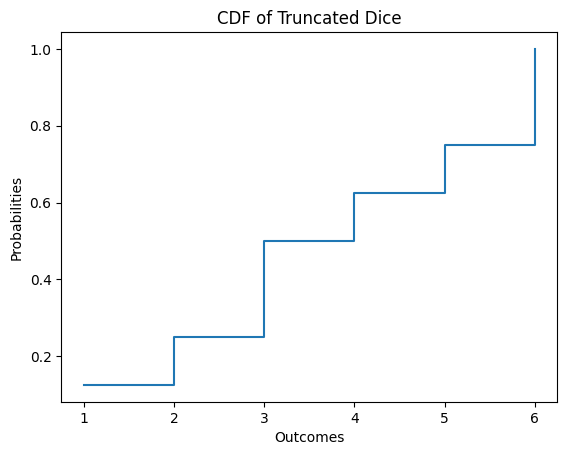

In [7]:
# Cummulative sum of the probabilities
p = np.cumsum(probabilities)

plt.step(range(1, 7), p, where='post')
plt.title('CDF of Truncated Dice')
plt.xlabel('Outcomes')
plt.ylabel('Probabilities')
plt.xticks(np.arange(1, 7, 1))
plt.show()

#Expectation, Median, Mode and Variance

##Mean or Expectation
The expectation or mean of a random variable X denoted as E(X) is defined as

$E(X) = \sum_{x𝜖𝕏}{xp(x)}$

The expectation can be interpreted as the mean value of a large number of observations from the random variable X. Consider again the example of the biased dice. The expectation is

$E(X) = 1\cdot 1/8 + 2\cdot 1/8 + 3\cdot 2/8 + 4\cdot 1/8+ 5\cdot 1/8 + 6\cdot 2/8 = 3.75$

Therefore, if we were to roll the dice a large number of times, we would expect the mean of the number shown to be 3.75.

##Median
The median of the random variable X denoted as $M(X)$ is defined as the value x such that $P(X ≤ x)$ is greater than or equal to 0.5 and $P(X ≥ x)$ is greater than or equal to 0.5. It is defined as the middle value of the distribution. For the dice example the median is the range $[3,4]$ : indeed

$P(X ≤ 3) = P(X = 1)+ P(X=2) + P(X=3) = 4/8 ≥ 0.5$

$P(X ≥ 3) = P(X=3) + P(X=4)+ P(X=5) + P(X=6) = 6/8 ≥ 0.5$


$P(X ≤ 4) = P(X = 1)+ P(X=2) + P(X=3)+ P(X=4) = 5/8 ≥ 0.5$
$P(X ≥ 4) = P(X=4)+ P(X=5) + P(X=6) = 4/8 ≥ 0.5$

Traditionally you would take the middle point between the 2 values and say that 3.5 is *A* median but giving the range is also fine.

Some textbooks say the median is the lowest value of x where $P(X)$ is greater than or equal to 0.5 which in this example is 3.

##Mode
The mode of the random variable X is the value x such that $P(x)$ is the greatest: it is the value of the random variable which is expected to happen most frequently.

Notice that the mode may not be unique: in that case we say that the distribution of X is bimodal. The example of the biased dice as an instance of a bimodal distribution: the values 3 and 6 are the equally likely and they have the largest pmf.

##Variance
The previous three summaries are measures of centrality: they describe the central tendency of X.

Measures of variability are measures that quantify the spread or the variation of the possible values of X around the mean.

The variance of the discrete random variable X is the expectation of the squared difference between the random variable and its mean. Formally it is defined as

 $V(X) = E((X - E(X))^2) = ∑x𝜖𝕏(x - E(X))^2 p(x)$

But mostly we can get by using the shortcut:

$Var(X)=E[X^2]−(E[X])^2$

In our dice example,

$E(X) = 1\cdot 1/8 + 2\cdot 1/8 + 3\cdot 2/8 + 4\cdot 1/8+ 5\cdot 1/8 + 6\cdot 2/8 = 3.75$

$E[X^2] = 1^2\cdot 1/8  + 2^2\cdot 1/8 + 3^2\cdot 2/8 + 4^2\cdot 1/8  + 5^2\cdot 1/8  + 6^2\cdot 2/8 = 17$

$= 17 - (3.75)^2$

$=17 - 14.0625$

$Var(X) = 2.9375$

#Simulating a RV that follows a Bernoulli Distribution


In the previous section we gave a generic definition of discrete random variables and discussed the conditions that a pmf must obey. We considered the example of a biased dice and constructed a $pmf$ for that specific example.
There are situations that often happen in practice: for instance the case of experiments with binary outcomes. For such cases random variables with specific $pmfs$ are given a name and their properties are well known and studied.

As we have said, a random variable has a probability distribution that represents the likelihood that any of the possible values would occur.
Consider an experiment or a real-world system where there can only be two outcomes:

* a toss of a coin: heads or tails;
* the result of a pregnancy or flu test: positive or negative;
* the status of a machine: broken or working;

By default one outcome happens with some probability, that we denote as $p∈[0,1]$ and the other with probability $1−p$.

Such a situation is modeled using the so-called Bernoulli distribution with parameter $p$. One outcome is associated to the number $1$ (usually referred to as success) and the other is associated to the number $0$ (usually referred to as failure). So $P (X = 1) = p(1) = p$ and $P(X = 0) = p(0) = 1 - p$.

$$
p(x) = \begin{cases}
p^x (1-p)^{1-x} & \text{if } x = 0,1 \\
0 & \text{otherwise }
\end{cases}
$$

The mean and variance of the Bernoulli distribution (if one outcome is 1 and the other one is 0) can be easily computed as

* $E(X) = 0 * (1-p) + 1 * p = p$
* $V(X) =  0^2*(1-p) + 1^2 (p) - p^2 = p(1-p)$

Python doesn’t provides a specific method for the **Bernoulli distribution**, but as we will see in the next section, this is a specific case of the **binomial experiment (with just 1 trial)**, so we will use the binomial method for working with the Bernoulli distribution in Python numpy. We will explain this function below, for now let’s see a couple examples of the Bernoulli  $Ber(p =0.25)$ distribution in Python.

In [10]:
print(stats.binom.pmf(0, 1, 0.25)) #number of successes i am interested in, run trial 1 time, probability of success is 0.25 or what is the probability of getting exactly 0 successes?
print(stats.binom.pmf(1, 1, 0.25)) #number of successes i am interested in, run trial 1 time, probability of success is 0.25 or what is the probability of getting exactly 1 success?
print(np.random.binomial(1, 0.25, 20))#generate 20 experiements, each with 1 trial that has a 25% chance of success

#what if i want to do multiple Bernoulli tests?
print(stats.binom.pmf(25, 100, 0.25))#what is the probability of getting exactly 25 successes in 100 trials each with a 25% probability of success, this is a binomial distribution

0.75
0.25
[0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0]
0.0917996917668368


# Simulating a RV that follows a Binomial Distribution

The Bernoulli random variable is actually a very special case of the Binomial random variable. Consider experiments of the type discussed for Bernoulli’s: coin tosses, COVID tests etc. Now suppose that instead of having just one trial, each of these experiments are repeated multiple times. Consider the following assumptions:

* each experiment is repeated $n$ times;
* each time there is a probability of success $p$;
* the outcome of each experiment is independent of the others.

Let’s think of tossing a coin $n$ times. Then we would expect that the probability of showing heads is the same for all tosses and that the result of previous tosses does not affect others. So this situation appears to meet the above assumptions and can be modeled by what we call a Binomial random variable.

Formally, the random variable $X$ is a Binomial random variable with parameters $n$ and $p$ if it denotes the number of successes of $n$ independent Bernoulli random variables, all with parameter $p$.

$$
p(x) = \begin{cases}
\binom{n}{x} p^{x} (1-p)^{n-x} & \text{where } x \in {0, 1, 2, ..., n} \\
0 & \text{otherwise }
\end{cases}
$$

* If $X = x$ there are $x$ successes and each success has a probability $p$, so $p^x$ counts the overall probability of successes.
* If $X = x$ there are $n - x$ failures and each failure has a probability $1 - p$, so $(1 - p)^{n-x}$ counts the overall probability of failures.
* Failures and successes can appear according to many orders. To see this, suppose that $x = 1$: there is only one success out of $n$ trials. This could have happened in the first trial, the second or the nth. The term $\binom{n}{x}$ counts all the possible ways the outcome $x$ could have happened.

The Bernoulli distribution can be seen as a special case of the Binomial where the parameter $n$ is fixed to $1$.

We will not show why this is the case but the expectation and the variance of the Binomial random variable with parameters $n$ and $p$ can be derived as

* $E(X) = np$,
* $V(X) = np(1-p)$

The formulae for the Bernoulli can be retrieved by setting $n = 1$.

Below, we will see the pmf of two Binomial distributions:

**First figure:**

$n = 10, p = 0.3$ → In this figure, we can see that the number of successes is more likely to be small. Being 3 successes what seems more likely (a little more than 25% probability to happen).


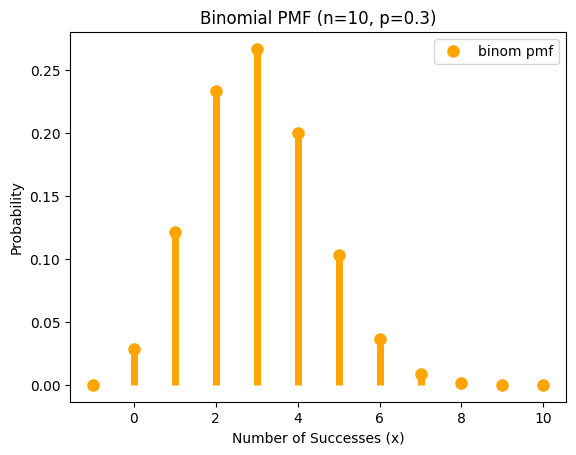

In [15]:
n = 10 #number of trials
p = 0.3 #Chance of success per trial

x = np.arange(stats.binom.ppf(0, n, p), stats.binom.ppf(1, n, p)+1)
#note we are using the percent point function also known as a quantile function, lower and upper bound
#Defines the range of x-values to plot — the possible number of successes (0 to 10).
#This line creates a list of all possible outcomes of a binomial random variable — from the minimum possible number of successes to the maximum —
# so that we can plot or compute probabilities for each one. You could also write np.arange(0,n+1) but this is more robust


fig, ax = plt.subplots(1, 1)

ax.plot(x, stats.binom.pmf(x, n, p), 'o',color='orange', ms=8, label='binom pmf')
ax.vlines(x, 0, stats.binom.pmf(x, n, p), colors='orange', lw=5)

plt.xlabel("Number of Successes (x)")
plt.ylabel("Probability")
plt.title("Binomial PMF (n=10, p=0.3)")
plt.legend(loc='best')

plt.show()

n = 10, p = 0.3 → In this figure, we can see that the number of successes is more likely to be small. Being 3 successes what seems more likely (a little more than 25% probability to happen).


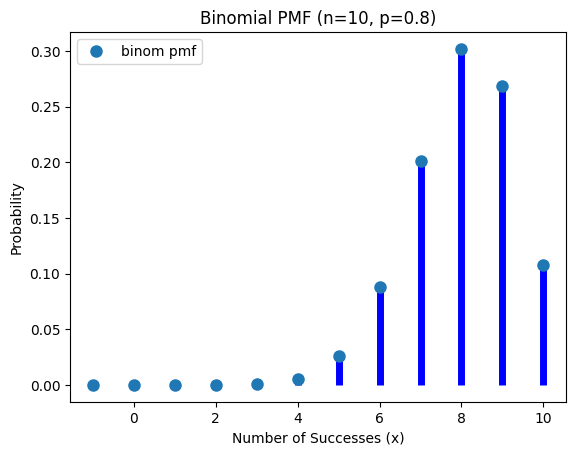

In [16]:
n = 10
p = 0.8
x = np.arange(stats.binom.ppf(0, n, p), stats.binom.ppf(1, n, p)+1)
pmf = stats.binom.pmf(x, n, p)

plt.vlines(x, 0, pmf, colors='b', lw=5)
plt.plot(x, pmf, 'o', markersize=8, label='binom pmf')
plt.xlabel("Number of Successes (x)")
plt.ylabel("Probability")
plt.title("Binomial PMF (n=10, p=0.8)")
plt.legend(loc='best')
plt.show()

n = 10, p = 0.8 → In this figure, we can see that the number of successes is more likely to be large. Being 8 successes what seems more likely (close to 30% probability to happen).


Python provides a straightforward implementation of the Binomial distribution through the functions `binom.pmf` for the pmf and `binom.cdf` for the cdf. They require three arguments:

the value at which to compute the pmf or the cdf;

the size of the Binomial;

the parameter p of the Binomial.


In [18]:
#What is the pmf at X=3, for 10 trials, with 30% chance of success

stats.binom.pmf(3, 10, 0.3)

np.float64(0.26682793199999977)

In [21]:
#What is the pmf at X=8, for 10 trials, with 80% chance of success

print(stats.binom.cdf(8, 10, 0.8))
print(stats.binom.pmf(8, 10, 0.8))

0.6241903615999999
0.30198988799999993


Python also provides a method for generating pseudo-random numbers using a binomial distribution through the function `np.random.binomial`. This function will require three arguments:

n is the parameter n of the Binomial;

p is the parameter p of the Binomial;

Size is the parameter for specifying the number of pseudo-random numbers we want to generate;

Imagine a coin toss experiement. We toss a coin 20 times (20 trials) for each experiment. We will do 100 experiements. There is a 50% chance of success per trial. How many heads do we get per experiment?


In [22]:
#n = number of trials, p= chance of success, size = how many experiments


print(np.random.binomial(n = 20, p = 0.5, size = 100))

[14  9 10 12 11  8 15  3 11  6 10 13 13 10  8 11 10 10  8 10  5 11 12  8
  9 11 12 13  9 12 10 13 16 11 12  8  9 12 14  5 14  9 13  7  6  9  7  8
  8 10  8 12  5  9 14  7 13  5  7  5 11  7 12  9  9 13 10 10 14  8  8 12
  8  8  9 14 12 11 13  9 13  7  8 15 10 11  9  7 11 13 11 10  8  9  8 12
 12 11  7  6]


# Simulating a RV that follows a Geometric Distribution

Imagine tossing a coin until you get the first “head”, or shooting free throws in basketball until you make the first basket.

We can also try to model the number of times we flip a switch and the bulb lights up until it fails, or the number of times an ATM gives us money until it fails.

The modeling of this kind of problems is achieved with the Geometric Distribution.

Imagine a continous Bernoulli experiment, of parameter p, until we get the first success.

Let X be the random variable that counts the number of failures before the first success.

$ P(FFF...FS) = P(F)^x \cdot P(S) = (1-p)^x \cdot p = q^x \cdot p$

* $F$ → failure
* $S$ → success
* $p$ → probability of success
* $q = 1 - p$ → probability of failure
* $x$ → number of failures before the 1st success


This form of the geometric distribution is used for modeling the number of failures until the first success. It’s probability distribution (pmf) is

$$
p_X(x) = P(X = x) = \begin{cases}
(1-p)^x \cdot p & \text{where } x \in {0, 1, 2, ...} \\
0 & \text{otherwise }
\end{cases}
$$

The random variable X defined above is said to follow a geometric distribution of $p$ parameter. We will denote it by $Ge(p)$. Its domain is $D_x \in \{ 0, 1, 2, 3,...\}$.

Say that we want to calculate $P(X ≤ 3)$ (cdf). By the property of the probability of the complementary event we have that


$P(X \leq 3) = 1 - P(X > 3) = 1- P(X \geq 4) $

The $X > 3$ tells us that we have failed 4 or more times before getting the first success. We can symbolize this event in the following way:

$ \{ X > 3 \} = \{ X \geq 4 \} = \{ FFFF \}$

Now, since the attempts are independent, we have that:

$ P(X > 3) = P( \{FFFF \}) = P(F) \cdot P(F) \cdot P(F) \cdot P(F) = (1-p)^4 $

Then, the value of the distribution function of X in x = 3 will be:

$F_x(3) = P(X ≤ 3) = 1 - P(X ≥ 4) = 1 - (1 - p)^4$

Generalizing, for any positive integer $k$:

$F_x(k) = P(X ≤ 3) = 1 - (1 - p)^{k+1}, \ if \ k = 0, 1, 2, 3,...$

Therefore, the $cdf$ is

$$
F_X(x) = P(X \leq x) = \begin{cases}
0, & \text{if } x < 0, \\
1-(1-p)^{k+1}, & \text{if } \begin{cases} k \leq x < k+1, \\ for \ k = 0,1,2,...
\end{cases}
\end{cases}
$$

With,

* Mean: $E(X) = \dfrac{1-p}{p}$,
* Variance: $Var(X) = \dfrac{1-p}{p^2}$

What if instead of counting number of failures until a success, we count the number of trials or attempts until success?The expectation increases by one and the variance stays the same.

Python provides a method for performing calculations with a geometric random variable. The `geom.pmf` (pmf) and `geom.cdf` (cdf) functions will have the next arguments:

* `k` (in dgeom) and q (in pgeom) will take the value of the geometric random variable we want to evaluate, in this case, Python will evaluate the number of attempts (be careful with this)
* `p` is the probability of success in each of the attempts

Let’s see some examples for the geometric distribution $Ge(p = 0.25)$.

$P(X = 2) = (1 - 0.25)^{2-1} \cdot 0.25 = 0.1875$

$P(X ≤ 5) = 1 - (1 - 0.25)^{4+1} = 0.7626953$

In [23]:
#k = number of trials until first success, k = 2 means we fail 1 and succeed on the second trail
# P = chance of success

stats.geom.pmf(k = 2, p = 0.25)

np.float64(0.1875)

In [24]:
#k = number of trials until first success, what number do we put if we want the first success to be on the 5th trial?
# P = chance of success

stats.geom.cdf(k = 5, p = 0.25) # Probability that we succeed before or on the 5th trial

np.float64(0.7626953125)

In [25]:
# Generate 25 random numbers from a geometric distribution with a probability of success of 0.25
np.random.geometric(p=0.25, size=25)

array([ 1,  1,  1,  1,  7,  2,  4,  7,  1,  2,  7,  4,  3,  1,  8,  2,  8,
        8,  1,  6,  1,  1,  1, 16,  6])

##Graphing the geometric distribution

In the $pmf$, the probability of getting your first success after $x$ failures has a decreasing fashion because the probability of success is $0.25$ and, therefore, in the first attempt, we have a probability of $0.25$ of obtaining the first success after $0$ failures $(x = 0)$.

However, in the second attempt, the probability of obtaining the first success after $1$ failure $(x = 1)$ is lower because it has to be fulfilled that you failed in the first attempt and also that you succeed in the second one. In the same way, when $x = 2$ , the probability is lower because you have to fail in the first attempt, fail in the second and succeed in the third!
You can use the formulas of the pmf to demonstrate it.


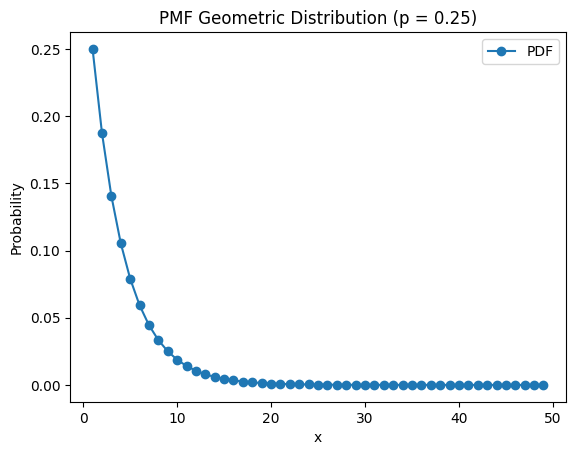

In [26]:
p = 0.25
x = np.arange(1, 50)
geom = stats.geom(p)
pdf = geom.pmf(x)

plt.plot(x, pdf, 'o-', label='PDF')
plt.legend()
plt.title('PMF Geometric Distribution (p = 0.25)')
plt.xlabel('x')
plt.ylabel('Probability')
plt.show()
# Likely that a success will happen before a large amount of trials

On the other hand, the $cdf$ shows the probability of success when the number of failures is less than or equal to $x$.

We can see that the probability of success when the number of failures is less than or equal to $0$ is $0.25$, which is the same as the probability of success of our first attempt. However, the probability of success when the number of failures is less than or equal to $30$, is much higher because it includes all the previous cases, therefore it is the sum of all the probabilities of previous $x$ values.

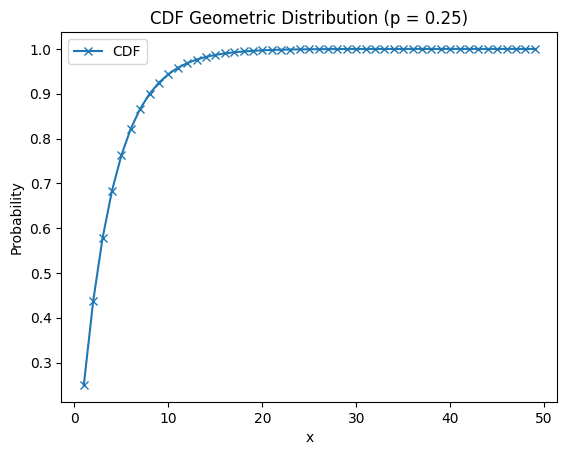

In [27]:
cdf = geom.cdf(x)

plt.plot(x, cdf, 'x-', label='CDF')
plt.legend()
plt.title('CDF Geometric Distribution (p = 0.25)')
plt.xlabel('x')
plt.ylabel('Probability')
plt.show()
# Success when x<=X

# Simulating a RV that follows a Poisson Distribution

The Poisson distribution is a discrete probability distribution, which describes the number of times an event occurs during a specific interval; which can be of time, distance, area, volume, among others.
For example, Poisson variables are: the number of calls received by a telephone exchange in a period of 1 minute, the number of bacteria in a volume of 1 liter of water or the number of faults on the surface of a rectangular piece of ceramic.


In a Poisson distribution, the following assumptions are always met:
 * The random variable is the number of times an event occurs during a defined interval. The interval can be time, distance, area, volume or some similar unit.

 $X = \text{number of times an event occurs during a defined interval}$

* The probability of occurrence is the same for any 2 intervals of equal length.
* The occurrence or non-occurrence in any interval is independent of the occurrence or non-occurrence in any other interval.
* Two events cannot occur at exactly the same time.

If these conditions are met, the discrete random variable $X$ follows a Poisson distribution and we can apply the Poisson distribution formula

$$
p(x) = \begin{cases}
\dfrac{e^{-\lambda} \lambda^x}{x!}, & \text{where } x \in {0, 1, 2, ...} \\
0 & \text{otherwise }
\end{cases}
$$

where,

* $f(x) = P(X = x) = p(x)$ → probability of x occurrences in an interval
* $λ = E(X) = V(X)$ → mean number of events within a given interval
* $e$, constant, euler number, base for natural logarithms $= 2.71828$
* the sample space of a Poisson random variable is the set of all non-negative integers




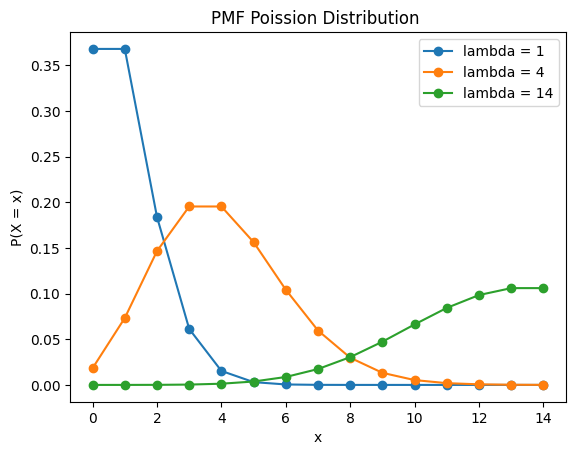

In [29]:
# Generate the x values (number of occurences)
x = np.arange(0, 15)

# Calculate the PMF with lambda equal to 1
pmf_lambda1 = stats.poisson.pmf(x, 1)

# Calculate the PMF with lambda equal to 4
pmf_lambda4 = stats.poisson.pmf(x, 4)

# Calculate the PMF with lambda equal to 14
pmf_lambda14 = stats.poisson.pmf(x, 14)

# Plot the PMFs
plt.plot(x, pmf_lambda1, 'o-', label='lambda = 1')
plt.plot(x, pmf_lambda4, 'o-', label='lambda = 4')
plt.plot(x, pmf_lambda14, 'o-', label='lambda = 14')


# Add labels and legend
plt.title('PMF Poission Distribution ')
plt.xlabel('x')
plt.ylabel('P(X = x)')
plt.legend()

# Show the plot
plt.show()

# For lambda=1 it is more likely to have one occurence in the time interval
# For lambda=4 it is more likely to have four occurrences in the time interval

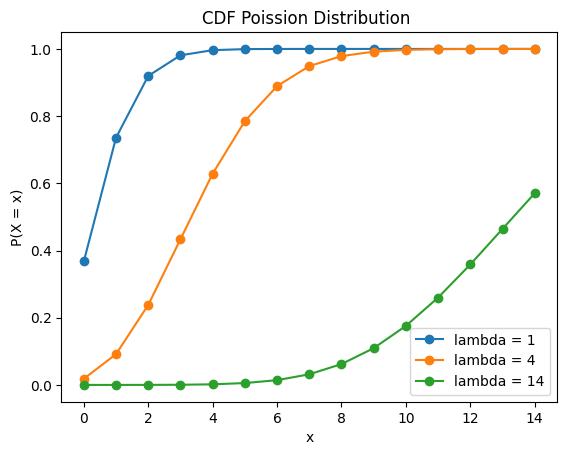

In [31]:
# Generate the x values (number of occurences)
x = np.arange(0, 15)

# Calculate the PMF with lambda equal to 1
cdf_lambda1 = stats.poisson.cdf(x, 1)

# Calculate the PMF with lambda equal to 4
cdf_lambda4 = stats.poisson.cdf(x, 4)

# Calculate the PMF with lambda equal to 14
cdf_lambda14 = stats.poisson.cdf(x, 14)

# Plot the PMFs
plt.plot(x, cdf_lambda1, 'o-', label='lambda = 1')
plt.plot(x, cdf_lambda4, 'o-', label='lambda = 4')
plt.plot(x, cdf_lambda14, 'o-', label='lambda = 14')

# Add labels and legend
plt.title('CDF Poission Distribution ')
plt.xlabel('x')
plt.ylabel('P(X = x)')
plt.legend()

# Show the plot
plt.show()

The interesting thing about Poisson variables is that we can modify (if the model allows it) the time interval $(0, t]$ in which we count the events. Of course, this does not necessarily have to be possible. But in general if the variable is poisson in $(0, t]$ it will be also in any sub-interval $(0, t’]$ for all $t’$ such that $0 < t’ < t$.
So we will be able to define a series of variables $X_t$ of distribution $Po(t)$.

Let’s consider a Poisson experiment with $λ$ equal to the average number of events in a unit of time. If $t$ is an amount of time in time units, the random variable $X_t = \text{number of events in the interval } (0,t]$ is a $Po(λ⋅t)$. The set of variables {Xt}t>0 is called a Poisson process.

Python provides a straightforward implementation of the Poisson distribution through the stats library, using the functions `poisson.pmf` for the pmf and `poisson.cdf` for the cdf. They require two arguments:
* first argument is the value at which to compute the pmf or the cdf;
* second is the parameter $λ$ of the Poisson;

So for instance `poisson.pmf` returns  $P(X=3) = p(3)$ for a Poisson random variable with parameter $λ = 1$.

In [32]:
stats.poisson.pmf(3,1)

np.float64(0.06131324019524039)

In [33]:
stats.poisson.cdf(8,4)

np.float64(0.9786365655120158)

In [34]:
np.random.poisson(4,100)

array([ 3,  4,  4,  0,  4,  4,  4,  4,  5,  5,  4,  6,  5,  2,  5,  2,  2,
        4,  5,  5,  5,  3,  6,  5,  5,  3,  5,  2,  4, 11,  2,  5,  3,  4,
        6,  0,  1,  1,  6,  6,  3,  5,  3,  4,  6,  3,  3,  4,  4,  5,  2,
        2,  9,  2,  4,  2,  2,  7,  3,  6,  8,  7,  4, 10,  3,  3,  8,  3,
        4,  7,  3,  6,  8,  3,  4, 11,  4,  4,  2,  4,  4,  6,  4,  4,  3,
        7,  3,  5,  7,  2,  6,  2,  6,  3,  4,  3,  5,  7,  3,  4])

#Excercises in Discreet Random numbers

##Funding needed
You are an entrepreneur looking for funding. You have decided to do an email campaign to potential investors and based on your market research you know each email sent has a 30% chance of being opened by the recipient.

Simulate the results of sending 100 emails. Calculate the proportion of emails opened.


In [36]:
# Parameters
p = 0.3 # Probability of an email being opened
n = 100 # Number of emails sent

#setting a seed for reproduceability
np.random.seed(2025)

# Generate random numbers
bernoulli_data = np.random.binomial(1, p, n)

# Calculate proportion of emails opened
proportion_opened = np.mean(bernoulli_data) #get the mean of the array above
print("Proportion of Emails Opened:", proportion_opened)

Proportion of Emails Opened: 0.31


##Newage gambling

A new mystery box line was released and everyone is after the super rare item that only has a 5% chance of appearing.

Each customer can only buy 10 boxes at a time to manage the demand.

Simulate 50 customers. How many customers receieved the super rare item? What is the average number of rare items customers received?

In [45]:
# Parameters
n_trials = 10 # Boxes per customer
p = 0.05 # Probability of rare item
n = 50 # Number of customers

#setting a seed for reproduceability
np.random.seed(2025)

# Generate random numbers
binomial_data = np.random.binomial(n_trials, p, n)

print(binomial_data)
print("number of customers who got the item:",np.count_nonzero(binomial_data))

# Calculate average number of successes
average_successes = np.mean(binomial_data)
print("Average super rare items per customer:", average_successes)

# Who got the most figures
max_sucesses = np.max(binomial_data)
print("Most rare items received:", max_sucesses)


[0 1 2 0 0 0 1 0 2 1 0 1 0 1 0 0 1 1 0 0 1 2 0 0 2 2 0 0 0 0 0 3 0 1 0 0 0
 1 2 0 2 0 1 1 0 1 0 0 0 0]
number of customers who got the item: 21
Average super rare items per customer: 0.6
Most rare items received: 3



##Sliding into DMs
You message random people on your dating app hoping to make a connection. Each time, there is a 10% chance of getting an instant reply. You send messages non-stop until you receive a reply.

Simulate this process 30 times to determine the average number of messages sent before receiving a reply.


In [42]:
# Parameters
p = 0.1
n = 30

#setting a seed for reproduceability
np.random.seed(2025)

# Generate random numbers
geometric_data = np.random.geometric(p, n)

# Calculate the mean
mean_DMs = np.mean(geometric_data)
print("Mean Number of DMs sent:", mean_DMs)

Mean Number of DMs sent: 11.266666666666667


##Project Status

You work for a micromanager who sends an average of 3 “What is the status of the project?” messages per hour.

Simulate the number of messages received in 400 hours.

Calculate the variance to understand the variability in messages received.
Do the same for the mean.
Find the most number of messages sent in 1 hour.


In [47]:
# Parameters
lam =  3 # Average number of messages per hour
n =  400 # Number of hours

#setting a seed for reproduceability
np.random.seed(2025)

# Generate random numbers
poisson_data = np.random.poisson(lam, n)

print(poisson_data)
# Calculate variance
variance_annoyances = np.var(poisson_data)
print("Variance in annoyances:", variance_annoyances)
# Calculate mean
mean_annoyances = np.mean(poisson_data)
print("average number of annoyances:", mean_annoyances)
# Find Max
max_annoyances = np.max(poisson_data)
print("Max annoyances sent in a hour:", max_annoyances)

[4 5 1 1 3 4 4 0 4 4 6 1 3 1 5 6 4 3 1 2 2 2 1 1 3 2 4 3 1 4 2 2 2 3 2 1 3
 4 1 1 3 2 2 4 4 2 2 4 6 5 3 4 4 4 2 4 3 4 4 2 5 5 1 3 4 6 5 4 2 4 3 2 2 2
 1 2 5 6 2 2 3 0 4 0 2 1 4 7 2 1 2 3 4 7 2 3 3 1 0 4 2 2 4 1 2 3 3 2 2 3 4
 3 4 3 2 3 4 2 3 2 1 1 2 4 3 1 4 2 3 2 3 2 5 0 5 2 1 2 6 6 2 7 5 4 4 1 1 3
 7 2 3 3 3 1 1 3 4 2 2 0 1 2 3 2 3 3 1 2 4 2 6 0 3 1 5 5 3 3 4 2 3 2 3 3 4
 0 4 2 2 7 3 2 0 2 7 0 6 6 1 0 4 3 2 1 0 1 6 3 0 6 2 3 5 8 1 8 4 2 6 2 2 4
 1 1 3 2 2 3 2 4 3 2 1 4 4 8 3 2 6 5 2 1 0 3 2 3 3 2 2 0 4 3 2 3 3 1 6 3 4
 0 1 5 5 3 4 1 2 7 3 4 5 3 4 2 7 0 4 0 4 4 6 4 1 3 2 1 2 6 2 7 1 6 1 2 2 3
 3 2 9 7 6 3 6 8 3 2 6 1 5 3 4 1 3 3 1 2 2 0 1 1 3 2 3 5 3 4 1 3 4 2 5 2 5
 2 4 1 0 4 3 2 3 5 4 4 1 4 3 2 6 3 5 7 2 1 4 3 1 1 5 3 4 3 2 6 2 3 2 3 1 8
 6 1 1 1 7 4 1 4 3 1 5 5 3 3 3 4 2 3 3 3 1 0 5 2 3 5 1 3 3 8]
Variance in annoyances: 3.25
average number of annoyances: 3.0
Max annoyances sent in a hour: 9
